Imports

In [1]:
import sys
import os

sys.path.append(
    os.path.abspath("../src")
)

print(sys.path[-1])

c:\Users\SHREEYASH\OneDrive\Desktop\credit-default-prediction\src


Imports

In [2]:
from preprocess import (
    load_data,
    engineer_features,
    split_data,
    build_preprocessor
)

from fairness import (
    prepare_protected_attributes,
    compute_metric_frame,
    compute_fairness_scalars,
    mitigate_reweighing
)

Load Dataset

In [3]:
df = load_data("../data/GermanCredit.csv")

df = engineer_features(df)

2026-05-21 02:16:14.167 | INFO     | preprocess:load_data:67 - Loading dataset from: ../data/GermanCredit.csv
2026-05-21 02:16:14.187 | INFO     | preprocess:load_data:79 - Dataset shape: (1000, 21)
2026-05-21 02:16:14.191 | INFO     | preprocess:engineer_features:143 - Feature engineering complete. New features: debt_burden, age_group, monthly_credit_amount


Split Data

In [4]:
(
    X_train_original,
    X_test_original,
    y_train_original,
    y_test,
    protected_train,
    protected_test
) = split_data(df)

2026-05-21 02:16:17.909 | INFO     | preprocess:split_data:252 - Train size : 800 rows
2026-05-21 02:16:17.909 | INFO     | preprocess:split_data:253 - Test size  : 200 rows
2026-05-21 02:16:17.910 | INFO     | preprocess:split_data:254 - Train class dist: Counter({1: 560, 0: 240})
2026-05-21 02:16:17.910 | INFO     | preprocess:split_data:255 - Test class dist : Counter({1: 140, 0: 60})


Sanity Check

In [5]:
print(type(X_train_original))
print(X_train_original.shape)

print(X_train_original.columns)

<class 'pandas.DataFrame'>
(800, 22)
Index(['status', 'credit_history', 'purpose', 'savings', 'employment_duration',
       'personal_status_sex', 'other_debtors', 'property',
       'other_installment_plans', 'housing', 'job', 'telephone',
       'foreign_worker', 'duration', 'amount', 'installment_rate',
       'present_residence', 'age', 'number_credits', 'people_liable',
       'debt_burden', 'monthly_credit_amount'],
      dtype='str')


Protected Attributes

In [6]:
protected_groups_train = prepare_protected_attributes(
    protected_train
)

protected_groups_test = prepare_protected_attributes(
    protected_test
)

In [7]:
print(X_train_original.columns.tolist())

['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker', 'duration', 'amount', 'installment_rate', 'present_residence', 'age', 'number_credits', 'people_liable', 'debt_burden', 'monthly_credit_amount']


Build a Preprocessor

In [8]:
preprocessor = build_preprocessor()

preprocessor.fit(X_train_original)

print("Preprocessor fitted ✓")

Preprocessor fitted ✓


Transform train/test

In [9]:
X_train_t = preprocessor.transform(
    X_train_original
)

X_test_t = preprocessor.transform(
    X_test_original
)

print(X_train_t.shape)
print(X_test_t.shape)

(800, 63)
(200, 63)


Model training

In [13]:
from xgboost import XGBClassifier

model = XGBClassifier(

    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,

    random_state=42
)

model.fit(
    X_train_t,
    y_train_original
)

print("Model trained ✓")

Model trained ✓


Protected Attributes

In [14]:
protected_groups_train = prepare_protected_attributes(
    protected_train
)

protected_groups_test = prepare_protected_attributes(
    protected_test
)

Verify Alignment

In [15]:
print(len(X_train_t))
print(len(y_train_original))
print(len(protected_groups_train["gender"]))

800
800
800


Baseline Model Predictions

In [16]:
y_prob = model.predict_proba(
    X_test_t
)[:,1]

y_pred = model.predict(
    X_test_t
)

Before Mitigation Metrics

In [17]:
mf_gender_before = compute_metric_frame(

    y_test.values,

    y_pred,

    y_prob,

    sensitive_feature=
        protected_groups_test["gender"],

    attr_name="gender"
)

scalars_gender_before = compute_fairness_scalars(

    y_test.values,

    y_pred,

    y_prob,

    sensitive_feature=
        protected_groups_test["gender"],

    attr_name="gender"
)

2026-05-21 02:21:30.915 | INFO     | fairness:compute_metric_frame:118 - Computing MetricFrame for: gender
2026-05-21 02:21:31.039 | INFO     | fairness:compute_metric_frame:142 - 
Per-group metrics (gender):
                     selection_rate  false_positive_rate  false_negative_rate  \
sensitive_feature_0                                                             
Female                       0.6667                  0.5                 0.25   
Male                         0.7643                  0.5                 0.13   

                     accuracy  recall  precision  
sensitive_feature_0                               
Female                 0.6667    0.75     0.7500  
Male                   0.7643    0.87     0.8131  
2026-05-21 02:21:31.124 | INFO     | fairness:compute_fairness_scalars:212 - 
Fairness scalars (gender):
2026-05-21 02:21:31.124 | INFO     | fairness:compute_fairness_scalars:213 -   Demographic Parity Diff  : 0.0976 (PASS)
2026-05-21 02:21:31.124 | INFO     | 

Apply ExponentiatedGradient

In [18]:
print("Applying ExponentiatedGradient...")

y_pred_mitigated = mitigate_reweighing(

    X_train=X_train_t,

    y_train=y_train_original,

    sensitive_train=
        protected_groups_train["gender"],

    X_test=X_test_t
)

print("Mitigation done ✓")

2026-05-21 02:21:49.142 | INFO     | fairness:mitigate_reweighing:510 - Applying ExponentiatedGradient (DemographicParity)...


Applying ExponentiatedGradient...


2026-05-21 02:21:49.540 | INFO     | fairness:mitigate_reweighing:528 - ExponentiatedGradient applied ✓


Mitigation done ✓


After Mitigation Metrics

In [19]:
mf_gender_after = compute_metric_frame(

    y_test.values,

    y_pred_mitigated,

    y_prob,

    sensitive_feature=
        protected_groups_test["gender"],

    attr_name="gender"
)

2026-05-21 02:21:59.520 | INFO     | fairness:compute_metric_frame:118 - Computing MetricFrame for: gender
2026-05-21 02:21:59.555 | INFO     | fairness:compute_metric_frame:142 - 
Per-group metrics (gender):
                     selection_rate  false_positive_rate  false_negative_rate  \
sensitive_feature_0                                                             
Female                       0.7167                 0.60                0.225   
Male                         0.7143                 0.45                0.180   

                     accuracy  recall  precision  
sensitive_feature_0                               
Female                 0.6500   0.775     0.7209  
Male                   0.7429   0.820     0.8200  


In [20]:
scalars_gender_after = compute_fairness_scalars(

    y_test.values,

    y_pred_mitigated,

    y_prob,

    sensitive_feature=
        protected_groups_test["gender"],

    attr_name="gender"
)

2026-05-21 02:22:14.776 | INFO     | fairness:compute_fairness_scalars:212 - 
Fairness scalars (gender):
2026-05-21 02:22:14.776 | INFO     | fairness:compute_fairness_scalars:213 -   Demographic Parity Diff  : 0.0024 (PASS)
2026-05-21 02:22:14.776 | INFO     | fairness:compute_fairness_scalars:215 -   Demographic Parity Ratio : 0.9967 (PASS)
2026-05-21 02:22:14.776 | INFO     | fairness:compute_fairness_scalars:217 -   Equalized Odds Diff      : 0.1500 (FAIL)
2026-05-21 02:22:14.776 | INFO     | fairness:compute_fairness_scalars:219 -   Overall verdict          : FAIL ✗


Comparing Results

In [21]:
print("\nDP diff:")
print(
    f"{scalars_gender_before['demographic_parity_diff']:.4f}"
    f" -> "
    f"{scalars_gender_after['demographic_parity_diff']:.4f}"
)

print("\nEO diff:")
print(
    f"{scalars_gender_before['equalized_odds_diff']:.4f}"
    f" -> "
    f"{scalars_gender_after['equalized_odds_diff']:.4f}"
)


DP diff:
0.0976 -> 0.0024

EO diff:
0.1200 -> 0.1500


Detailed view

In [22]:
print("\n=== BEFORE ===")
print(mf_gender_before.by_group)

print("\n=== AFTER ===")
print(mf_gender_after.by_group)


=== BEFORE ===
                     selection_rate  false_positive_rate  false_negative_rate  \
sensitive_feature_0                                                             
Female                     0.666667                  0.5                 0.25   
Male                       0.764286                  0.5                 0.13   

                     accuracy  recall  precision  
sensitive_feature_0                               
Female               0.666667    0.75   0.750000  
Male                 0.764286    0.87   0.813084  

=== AFTER ===
                     selection_rate  false_positive_rate  false_negative_rate  \
sensitive_feature_0                                                             
Female                     0.716667                 0.60                0.225   
Male                       0.714286                 0.45                0.180   

                     accuracy  recall  precision  
sensitive_feature_0                               
Female       

Scalar Fairness Metrics

In [26]:
print("=== BEFORE ===")
print(scalars_gender_before)

print("\n=== AFTER ===")
print(scalars_gender_after)

=== BEFORE ===
{'attribute': 'gender', 'demographic_parity_diff': 0.0976, 'demographic_parity_ratio': 0.8723, 'equalized_odds_diff': 0.12, 'equalized_odds_ratio': 0.8621, 'roc_auc_overall': 0.761, 'dpd_passes': np.True_, 'eod_passes': False, 'dpr_passes': np.True_, 'passes_all_thresholds': False}

=== AFTER ===
{'attribute': 'gender', 'demographic_parity_diff': 0.0024, 'demographic_parity_ratio': 0.9967, 'equalized_odds_diff': 0.15, 'equalized_odds_ratio': 0.75, 'roc_auc_overall': 0.761, 'dpd_passes': np.True_, 'eod_passes': False, 'dpr_passes': np.True_, 'passes_all_thresholds': False}


Visualization

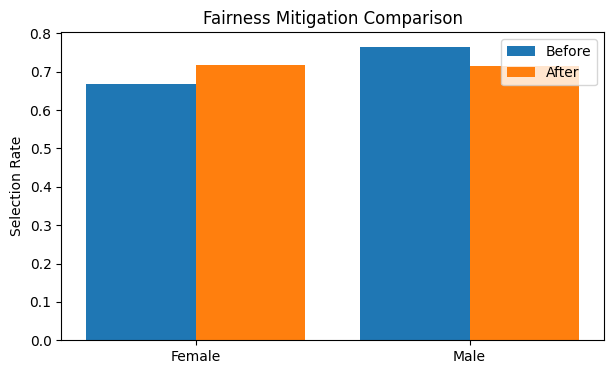

In [25]:
import matplotlib.pyplot as plt

groups=["Female","Male"]

before=[0.6667,0.7643]
after=[0.7167,0.7143]

plt.figure(figsize=(7,4))

x = range(len(groups))

plt.bar(
    [i-0.2 for i in x],
    before,
    width=0.4,
    label="Before"
)

plt.bar(
    [i+0.2 for i in x],
    after,
    width=0.4,
    label="After"
)

plt.xticks(x, groups)

plt.ylabel("Selection Rate")
plt.title("Fairness Mitigation Comparison")

plt.legend()

plt.show()